### WS 2020/21 <span style="float: right;">GET Lab<br />Paderborn University</span><br />
## <center>Digital Image Processing I<br /><br />Task Sheet 8</center>
---

### Overview

The objective of this exercise is to study spatial sharpening filters. The filter masks used for this purpose are based on first and second order derivatives. The following figure shows a subset of the most common masks for this:

<br />
<center><img src="images/masks.png"  width="800px" /></center>

---

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import time
import pprint
dpi = plt.rcParams['figure.dpi']

# plot grayscale image in original size
def plot_img_orig(img):
    rows, cols = img.shape # image size
    fig = plt.figure(figsize = (cols/dpi, rows/dpi))
    fig.add_axes([0, 0, 1, 1])
    plt.axis('off')
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.show()

#### <span style="color: RoyalBlue; font-weight: bold;">Task 8.1</span> Normalization and Clipping

Depending on the specific image processing method used (e.g., differentiating an image or adding it to another), the resulting gray values can exceed the common range of $[0, 255]$. While the exceeding values can be kept for further processing steps, the images cannot be displayed directly. In this case, there are two standard methods to adjust the values: normalization and clipping.

Normalization is a variant of range scaling and therefore a gray-level transformation, where the goal is the following mapping: $[a, b] \rightarrow [0, 255]$, where $[a, b]$ is the range of input gray values (see task sheet 3). The OpenCV function <a href="https://docs.opencv.org/4.2.0/d2/de8/group__core__array.html#ga87eef7ee3970f86906d69a92cbf064bd">`normalize` ↗</a> can be used to normalize an image in this way.

Clipping means that gray values smaller then $0$ are set to $0$, and that gray values larger then $255$ are set to $255$ (gray values exceeding the common range are clipped):

$$
f(x,y) =
\begin{cases}
0 &\ \mathrm{if}\ f(x,y) < 0\\
255 &\ \mathrm{if}\ f(x,y) > 255\\
f(x,y)   &\ \text{otherwise}
\end{cases}
$$

Implement / solve the following tasks:
1. Write a function for clipping a given image.
2. The image *h-pattern2.png* has three fields with the gray values $0$, $128$, and $255$, respectively. Read this image as a grayscale image and plot it.
3. To create an image with gray values which exceed the common range of $[0, 255]$, substract $128$ from each gray value and plot the result.
4. Normalize this image on the one hand, clip this image on the other hand, and plot and compare the results.

In [2]:
#8.1.1 clip given image
def clip(img):
    rows, cols = img.shape # image size

    # create copy of image
    res = img.copy()
    
    for iy in range(rows):
        for jx in range(cols):
            if res[iy, jx] < 0:
                res[iy, jx] = 0
            elif res[iy, jx] > 255:
                res[iy, jx] = 255
                
    # return result
    return res

Original:


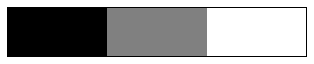

In [3]:
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/h-pattern2.png', 0).astype('float64') # change datatype to store arbitrary values
print("Original:")
plot_img_orig(img)

Substraction:


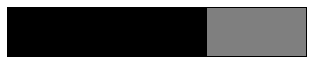

In [4]:
# substract 128 from each gray value and plot the result
img = img-128
#img = img-128
print("Substraction:")
plot_img_orig(img)

Normalization:


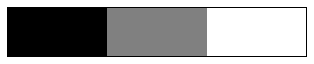

In [5]:
# normalize the image and plot the result
img_n = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
print("Normalization:")
plot_img_orig(img_n)

Clipping:


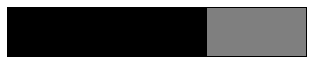

In [6]:
# clip the image and plot the result
img_c = clip(img)
print("Clipping:")
plot_img_orig(img_c)

As the results show, normalization brings back the original image (range of gray values). When displaying an image with exceeding gray values, the displayed image is automatically clipped, which is why the images after substraction and clipping are identical. The displayed image does not necessarily show the range of values stored in the corresponding variable. Exceeding values can still be stored and they are only clipped for display.

### <span style="color: RoyalBlue; font-weight: bold;">Task 8.2</span> Laplacian Filter

The Laplacian is the simplest isotropic derivative operator and can be implemented using one of the commonly used masks from the overview. As it is a derivative operator, it highlights gray-level discontinuities, and deemphasizes regions with slowly varying gray-levels. These properties can be exploited to enhance images: the background can be kept while integrating the sharpening effect of the Laplacian operation by subtracting (or adding) the original and the Laplacian images. Therefore:

$$
g(x,y) =
\begin{cases}
f(x,y)-\nabla^2 f(x,y) &\ \text{if the center coefficient is negative}\\
f(x,y)+\nabla^2 f(x,y) &\ \text{if the center coefficient is positive}\\
\end{cases}
$$

Implement / solve the following tasks:
1. Filter the image *fovea.jpg* using the first Laplacian mask and plot the clipped and normalized results.
2. Enhance the image using the given formula and plot the clipped and normalized results.
3. Repeat these tasks for the second Laplacian masks and compare the results.
4. Use one of the Laplacian masks with direct subtracting and show that the result is identical to using the given formula. 
5. What happens when the Laplacian filtered image is added instead of subtracted? Test it and explain the results.

Original:


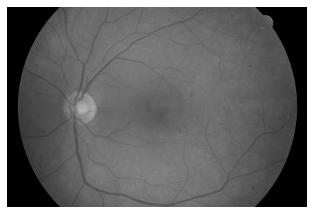

In [7]:
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/fovea.jpg', 0).astype('float64')
print("Original:")
plot_img_orig(img)

In [8]:
# === Laplacian mask (normal) ==================================================

# create Laplacian mask
laplace = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]])
print("Mask:", laplace)

Mask: [[ 0  1  0]
 [ 1 -4  1]
 [ 0  1  0]]


Laplacian filtered:


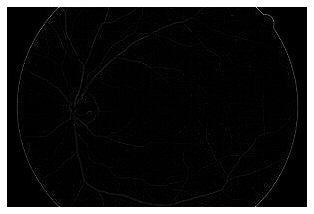

In [9]:
# filter the image
res_laplace = cv2.filter2D(img, cv2.CV_64F, laplace)
print("Laplacian filtered:")
plot_img_orig(res_laplace)

Normalized:


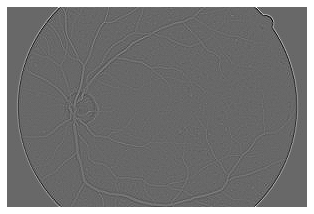

In [10]:
# normalize the image
res_laplace_n = cv2.normalize(res_laplace, None, 0, 255, cv2.NORM_MINMAX)
print("Normalized:")
plot_img_orig(res_laplace_n)

Enhanced normalized:


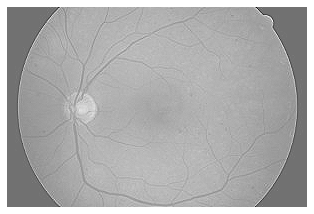

Enhanced clipped:


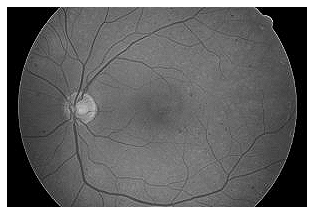

In [11]:
# enhanced image
res_laplace_e = img-res_laplace
res_laplace_e_n = cv2.normalize(res_laplace_e, None, 0, 255, cv2.NORM_MINMAX)
print("Enhanced normalized:")
plot_img_orig(res_laplace_e_n)
print("Enhanced clipped:")
plot_img_orig(res_laplace_e)


In [12]:
# === Laplacian mask (with diagonal terms) =====================================

# create Laplacian mask
laplace_diag = np.array([[1, 1, 1], [1, -8, 1], [1, 1, 1]])
print("Mask:")
print(laplace_diag)

Mask:
[[ 1  1  1]
 [ 1 -8  1]
 [ 1  1  1]]


Laplacian filtered:


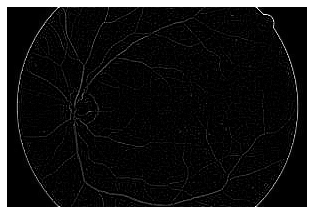

In [13]:
# filter the image
res_laplace_diag = cv2.filter2D(img, cv2.CV_64F, laplace_diag)
print("Laplacian filtered:")
plot_img_orig(res_laplace_diag)

Normalized:


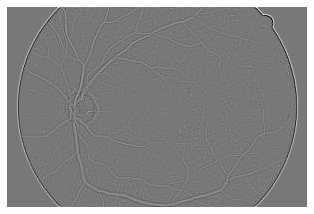

In [14]:
# normalize the image
res_laplace_diag_n = cv2.normalize(res_laplace_diag, None, 0, 255, cv2.NORM_MINMAX)
print("Normalized:")
plot_img_orig(res_laplace_diag_n)

Enhanced normalized:


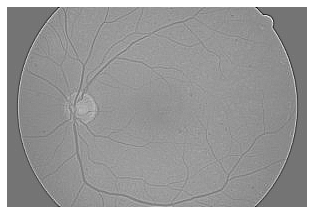

Enhanced clipped:


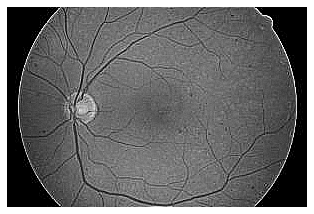

In [15]:
# enhanced image
res_laplace_diag_e = img-res_laplace_diag
res_laplace_diag_e_n = cv2.normalize(res_laplace_diag_e, None, 0, 255, cv2.NORM_MINMAX)
print("Enhanced normalized:")
plot_img_orig(res_laplace_diag_e_n)
print("Enhanced clipped:")
plot_img_orig(res_laplace_diag_e)

In [16]:
# === Laplacian mask with direct subtraction ===================================

# Laplacian mask with direct subtraction
laplace_diag_subt = np.array([[-1, -1, -1], [-1, 9, -1], [-1, -1, -1]])
print("Mask:")
print(laplace_diag_subt)

Mask:
[[-1 -1 -1]
 [-1  9 -1]
 [-1 -1 -1]]


Laplacian filtered:


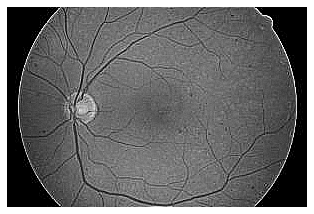

In [17]:
# filter the image
res_laplace_diag_subt = cv2.filter2D(img, cv2.CV_64F, laplace_diag_subt)
print("Laplacian filtered:")
plot_img_orig(res_laplace_diag_subt)

Difference:


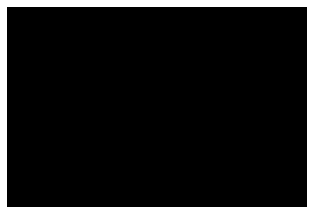

In [18]:
# difference to version with explicit subtraction
diff = res_laplace_diag_subt-res_laplace_diag_e
print("Difference:")
plot_img_orig(diff)

Adding instead of subtracting - clipped:


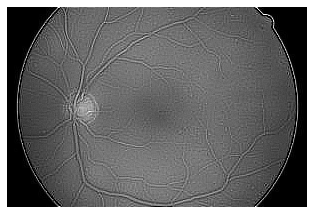

In [19]:
# === Adding instead of subtracting  ===========================================

res_laplace_diag_add = img+res_laplace_diag
print("Adding instead of subtracting - clipped:")
plot_img_orig(res_laplace_diag_add)

The result obtained with the mask with the diagonal terms is sharper than with the more basic mask. The final results are usually obtained by clipping, because the background in the normalized images is not kept and the results are grayish. The difference image shows that the alternative filter masks (with direct subtraction) can be used directly and that the results are automatically clipped for display.

If the Laplacian filtered image is added instead of subtracted, the image is not enhanced as intended. Instead, edges are highlighted. As can be seen in the Laplacian filtered image, the structures of interest (blood vessels) lead to positive (light) responses, while these structures are dark in the original image. Therefore, these structures are highlighted instead of sharpened.

### <span style="color: RoyalBlue; font-weight: bold;">Task 8.3</span> Laplacian of Gaussian (LoG) Filter

As a second-order derivative, the Laplacian is unacceptably sensitive to noise, which is why an image is often Gaussian smoothed before applying the Laplacian. Since the convolution operation is associative, the LoG mask can be precalculated in advance by differentiating the corresponding Gaussian. The result is given as follows (the prefactor of the Gaussian has been set to $1$ here; the result is different for the prefactor $1/2\pi\sigma^2$):

$$
\mathrm{LoG}(r) =
\left(\dfrac{r^2-2\sigma^2}{\sigma^4}\right)
e^{-\dfrac{r^2}{2 \sigma^2}}
$$

In this equation, $r$ is the distance from the center of the mask, where $r^2 = x^2 + y^2$.

Implement / solve the following tasks:
1. Write a function to create a $n\times n$ LoG mask ($n$ should be odd).
2. Reproduce the LoG mask from the overview as close as possible based on this function and print it.
3. Create a $301 \times 301$ Laplacian mask for $\sigma = 30$ and plot the mask coefficients as an image and as a function along the middle row (or column).
4. Filter the image *fovea.jpg* with the LoG mask from the overview. Plot and analyze the result.
5. Filter the image *moon-noise.png* with the Laplacian and mask and the LoG mask (use $\sigma = 2$ and $n = 21$ for the LoG). Plot and analyze the results with regard to edge detection.

In [20]:
# compute n x n LoG mask (n must be odd) with given sigma
def log_mask(sigma, n):
    # create empty mask
    log = np.zeros(shape=[n, n], dtype=np.float64) # init with zeros
    
    # fill mask
    c = int(n / 2) # center coordinates
    
    for iy in range(n):
        for jx in range(n):
            r2 = (iy-c)**2 + (jx-c)**2 # distance to the center squared
            log[iy, jx] = ((r2 - 2*(sigma**2)) / sigma**4) * np.exp(-r2 / (2*(sigma**2))) 
    
    return log

In [21]:
# reproduce mask from the overview as close as possible
log = -2*log_mask(0.5, 5)
log = log.astype('int64')
print(log)

[[ 0  0  0  0  0]
 [ 0  0 -2  0  0]
 [ 0 -2 16 -2  0]
 [ 0  0 -2  0  0]
 [ 0  0  0  0  0]]


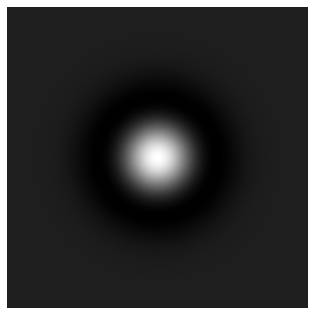

In [22]:
# create mask of given size
log = -log_mask(30, 301)
log_n = cv2.normalize(log, None, 0, 255, cv2.NORM_MINMAX)
plot_img_orig(log_n)

Negeative LoG coefficients:


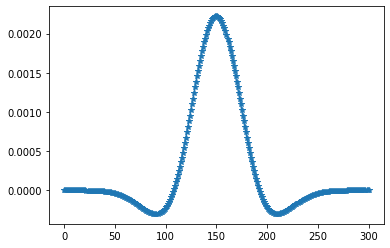

In [23]:
# plot middle row of the mask
idx = int(log.shape[0]/2)# total row: 301, we need middle row.
print("Negeative LoG coefficients:")
plt.plot(log[idx,:], marker='*')
plt.show()

Negative LoG coefficients normalized:


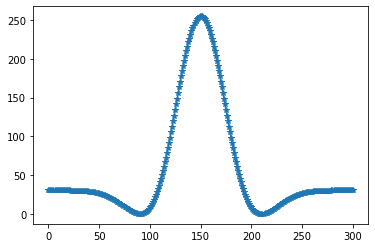

In [24]:
print("Negative LoG coefficients normalized:")
plt.plot(log_n[idx,:], marker='*')
plt.show()

[[ 0  0 -1  0  0]
 [ 0 -1 -2 -1  0]
 [-1 -2 16 -2 -1]
 [ 0 -1 -2 -1  0]
 [ 0  0 -1  0  0]]
LoG filtered:


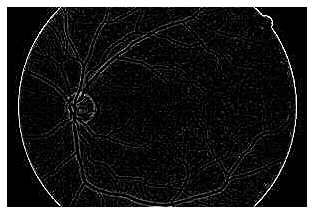

In [25]:
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/fovea.jpg', 0).astype('float64')

# filter image with LoG mask from overview
log = np.array([[0, 0, -1, 0, 0], [0, -1, -2, -1, 0], [-1, -2, 16, -2, -1], [0, -1, -2, -1, 0], [0, 0, -1, 0, 0]])
print(log)
res_log = cv2.filter2D(img, cv2.CV_64F, log)
print("LoG filtered:")
plot_img_orig(res_log)

LoG filtered normalized:


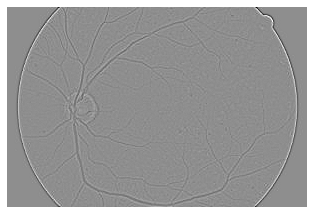

In [26]:
# normalize LoG filtered image
res_log_n = cv2.normalize(res_log, None, 0, 255, cv2.NORM_MINMAX)
print("LoG filtered normalized:")
plot_img_orig(res_log_n)

Original:


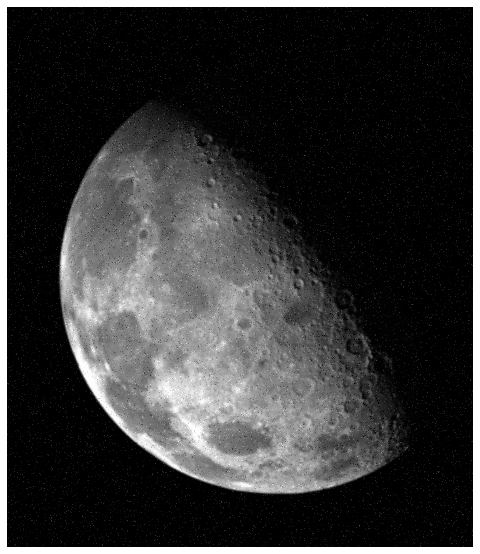

In [27]:
# moon image with noise
# read the image as a grayscale image (parameter 0)
log = log_mask(2, 21)
img = cv2.imread('images/moon-noise.png', 0).astype('float64')
print("Original:")
plot_img_orig(img)

Laplacian filtered:


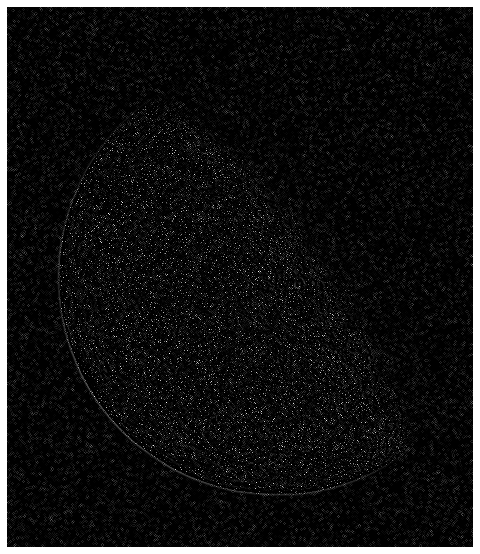

In [28]:
# Laplacian with and without normalization
res_laplace = cv2.filter2D(img, cv2.CV_64F, laplace)
print("Laplacian filtered:")
plot_img_orig(res_laplace)

Laplacian filtered normalized:


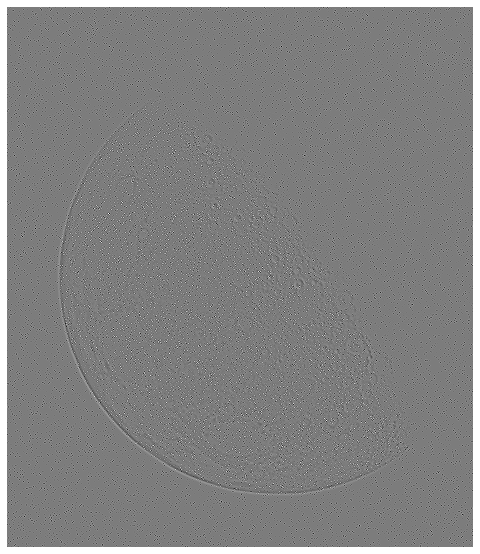

In [29]:
print("Laplacian filtered normalized:")
res_laplace_n = cv2.normalize(res_laplace, None, 0, 255, cv2.NORM_MINMAX)
plot_img_orig(res_laplace_n)

Laplace filtered normalized and thresholded:


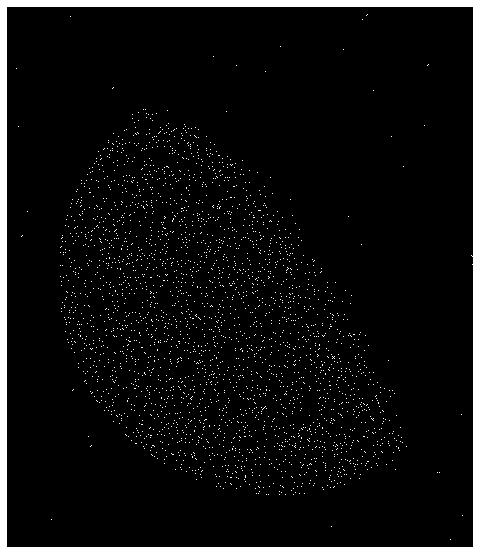

In [30]:
# Thresholded image
res_laplace_n_t = np.zeros(res_laplace.shape, dtype=np.float64)
indices = np.nonzero(res_laplace_n >= 160)
res_laplace_n_t[indices] = 255
print("Laplace filtered normalized and thresholded:")
plot_img_orig(res_laplace_n_t)

LoG filtered:


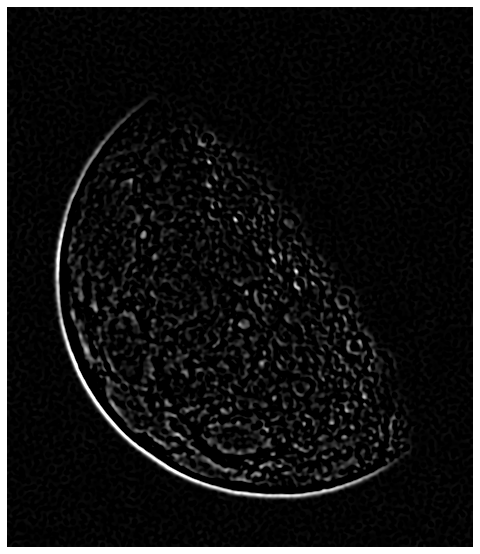

In [31]:
# LoG with and without normalization
res_log = cv2.filter2D(img, cv2.CV_64F, log)
print("LoG filtered:")
plot_img_orig(res_log)

LoG filtered normalized:


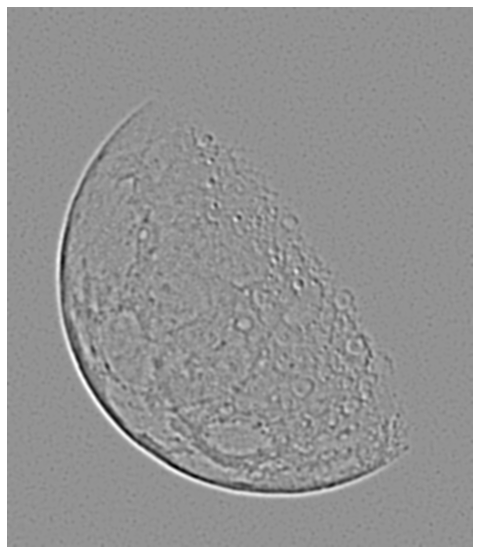

In [32]:
print("LoG filtered normalized:")
res_log_n = cv2.normalize(res_log, None, 0, 255, cv2.NORM_MINMAX)
plot_img_orig(res_log_n)

LoG filtered normalized thresholded:


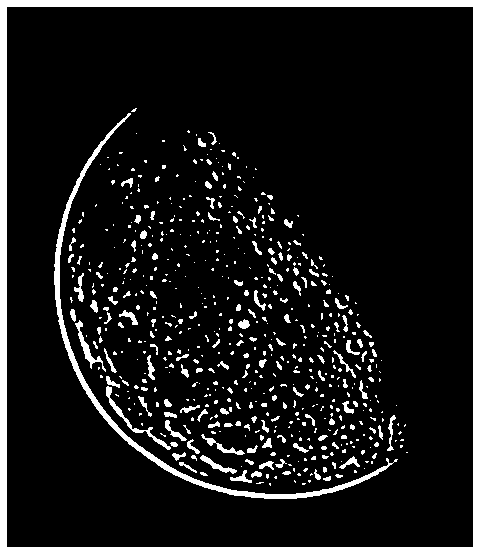

In [33]:
# Thresholded image
res_log_n_t = np.zeros(res_log.shape, dtype=np.float64)
indices = np.nonzero(res_log_n >= 160)
res_log_n_t[indices] = 255
print("LoG filtered normalized thresholded:")
plot_img_orig(res_log_n_t)

Note that the mask from the overview shows the negative of the LoG. Furthermore, the mask from the overview cannot be reproduced exactly. This is because the mask from the overview is only an approximation which is intended to reproduce the principal shape of the LoG (a positive central term surrounded by negative terms with increasing values for larger distances), where the coefficients sum to zero (so that the filtering result is zero for a homogenous region). Instead of using the formula, the LoG mask can also be created by first creating a Gaussian mask, and then applying the Laplacian to this mask.

The results show the edge detection capabilities of the LoG filter, especially in case of noise.

An alternative implementation is the sequential execution of the Gaussian and Laplacian filter. This method is slower than the LoG filter, because a
complete image has to be filtered twice, but the results are same (if the gaussian mask is large enough and the same standard deviation is used).

### <span style="color: RoyalBlue; font-weight: bold;">Task 8.4</span> Roberts (Cross) and Sobel Operator

First derivatives can be implemented using the magnitude of the gradient, which can be approximated using the Roberts and Sobel operator and the corresponding masks from the overview. The gradient is then typically approximated by the absolute values, for example, $|\nabla f| = |f_9 - f_5| + |f_8 - f_6|$ when using the two masks from the overview, taking the absolute values, and then summing up the results.

Implement / solve the following tasks:
1. Filter the image *p-building-small.png* with the masks of the Roberts Operator and plot the (normalized) results.
2. Repeat these tasks for the Sobel operator.
3. How do the results change when the image is rotated by 90 degrees?

In [34]:
# roberts operator
roberts_1 = np.array([[0, 0, 0], [0, -1, 0], [0, 0, 1]]); 
print(roberts_1)
roberts_2 = np.array([[0, 0, 0], [0, 0, -1], [0, 1, 0]]); 
print(roberts_2)

[[ 0  0  0]
 [ 0 -1  0]
 [ 0  0  1]]
[[ 0  0  0]
 [ 0  0 -1]
 [ 0  1  0]]


In [35]:
# sobel operator
sobel_1 = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]]); 
print(sobel_1)
sobel_2 = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]); 
print(sobel_2)

[[-1 -2 -1]
 [ 0  0  0]
 [ 1  2  1]]
[[-1  0  1]
 [-2  0  2]
 [-1  0  1]]


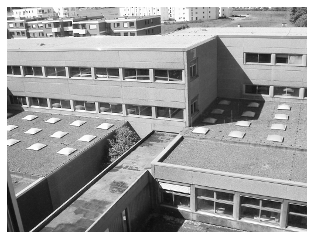

In [36]:
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/p-building-small.png', 0).astype('float64')
plot_img_orig(img)

Roberts:


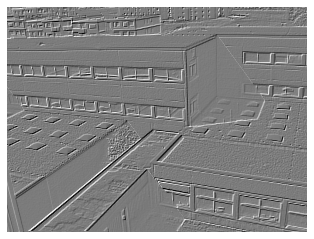

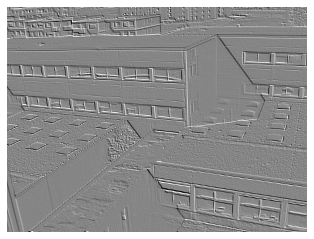

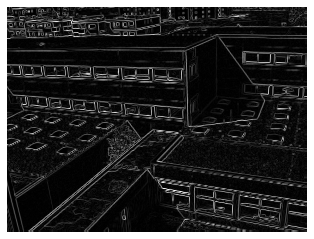

In [37]:
###########ROBERT###########
# filter images and plot the results
res_roberts_1 = cv2.filter2D(img, cv2.CV_64F, roberts_1)
res_roberts_2 = cv2.filter2D(img, cv2.CV_64F, roberts_2)

# normalize the results
res_roberts_1_n = cv2.normalize(res_roberts_1, None, 0, 255, cv2.NORM_MINMAX)
res_roberts_2_n = cv2.normalize(res_roberts_2, None, 0, 255, cv2.NORM_MINMAX)

# compute final results
res_roberts = np.abs(res_roberts_1) + np.abs(res_roberts_2)

# normalize the results
res_roberts_n = cv2.normalize(res_roberts, None, 0, 255, cv2.NORM_MINMAX)

# plot the results
print("Roberts:")
plot_img_orig(res_roberts_1_n)
plot_img_orig(res_roberts_2_n)
plot_img_orig(res_roberts_n)

Sobel:


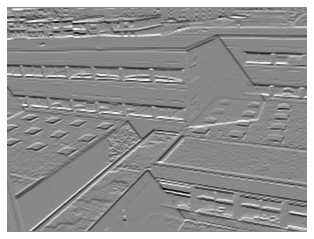

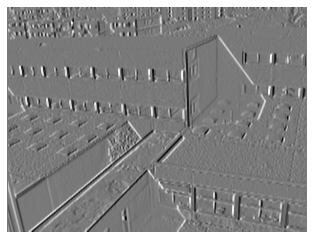

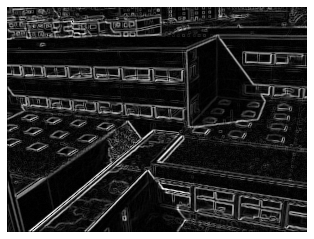

In [38]:
###########SOBEL###########
# filter images and plot the results
res_sobel_1 = cv2.filter2D(img, cv2.CV_64F, sobel_1)
res_sobel_2 = cv2.filter2D(img, cv2.CV_64F, sobel_2)

# normalize the results
res_sobel_1_n = cv2.normalize(res_sobel_1, None, 0, 255, cv2.NORM_MINMAX)
res_sobel_2_n = cv2.normalize(res_sobel_2, None, 0, 255, cv2.NORM_MINMAX)

# compute final results
res_sobel = np.abs(res_sobel_1) + np.abs(res_sobel_2)

# normalize the results
res_sobel_n = cv2.normalize(res_sobel, None, 0, 255, cv2.NORM_MINMAX)

# plot the results
print("Sobel:")
plot_img_orig(res_sobel_1_n)
plot_img_orig(res_sobel_2_n)
plot_img_orig(res_sobel_n)

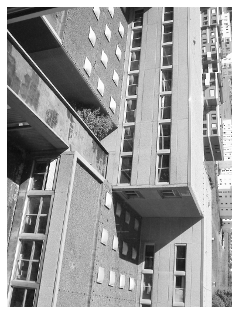

In [39]:
# rotate image (for your own tests)
img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE) # cv2.ROTATE_90_COUNTERCLOCKWISE to rotate back
plot_img_orig(img)

To see the differences, compare the filter results for diagonal structures when using Roberts, and horizontal and vertical structures when using Sobel. The filtering corresponds to a correlation. Therefore, the filter response is maximal when the image structure fits the filter structure, and minimal when it is most different. This can be seen when searching for such structures in the images.

When the image is rotated by 90 degrees, the individual filter responses will change, as the direction of diagonal structures change and horizontal structures become vertical. This because the partial derivatives which are approximated by the masks are not rotation invariant. Nonetheless, the final results will be identical, because the magnitude of the gradient is rotation invariant.

Roberts:


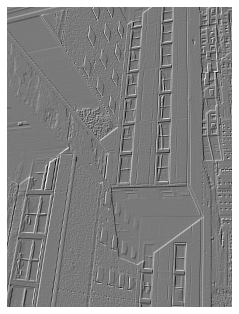

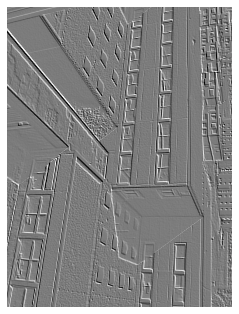

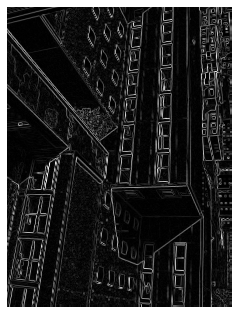

In [40]:
###########ROBERT90###########
# filter images and plot the results
res_roberts_1 = cv2.filter2D(img, cv2.CV_64F, roberts_1)
res_roberts_2 = cv2.filter2D(img, cv2.CV_64F, roberts_2)

res_sobel_1 = cv2.filter2D(img, cv2.CV_64F, sobel_1)
res_sobel_2 = cv2.filter2D(img, cv2.CV_64F, sobel_2)

# normalize the results
res_roberts_1_n = cv2.normalize(res_roberts_1, None, 0, 255, cv2.NORM_MINMAX)
res_roberts_2_n = cv2.normalize(res_roberts_2, None, 0, 255, cv2.NORM_MINMAX)

res_sobel_1_n = cv2.normalize(res_sobel_1, None, 0, 255, cv2.NORM_MINMAX)
res_sobel_2_n = cv2.normalize(res_sobel_2, None, 0, 255, cv2.NORM_MINMAX)

# compute final results
res_roberts = np.abs(res_roberts_1) + np.abs(res_roberts_2)
res_sobel = np.abs(res_sobel_1) + np.abs(res_sobel_2)

# normalize the results
res_roberts_n = cv2.normalize(res_roberts, None, 0, 255, cv2.NORM_MINMAX)
res_sobel_n = cv2.normalize(res_sobel, None, 0, 255, cv2.NORM_MINMAX)

# plot the results
print("Roberts:")
plot_img_orig(res_roberts_1_n)
plot_img_orig(res_roberts_2_n)
plot_img_orig(res_roberts_n)

Sobel:


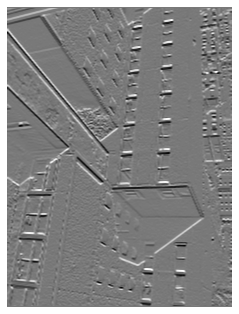

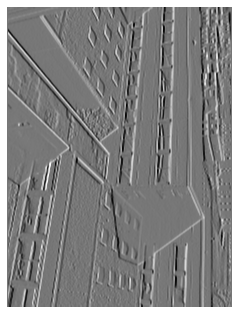

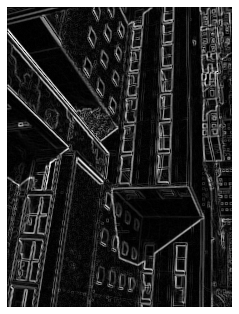

In [41]:
###########SOBEL90###########
# filter images and plot the results
res_sobel_1 = cv2.filter2D(img, cv2.CV_64F, sobel_1)
res_sobel_2 = cv2.filter2D(img, cv2.CV_64F, sobel_2)

# normalize the results
res_sobel_1_n = cv2.normalize(res_sobel_1, None, 0, 255, cv2.NORM_MINMAX)
res_sobel_2_n = cv2.normalize(res_sobel_2, None, 0, 255, cv2.NORM_MINMAX)

# compute final results
res_sobel = np.abs(res_sobel_1) + np.abs(res_sobel_2)

# normalize the results
res_sobel_n = cv2.normalize(res_sobel, None, 0, 255, cv2.NORM_MINMAX)

print("Sobel:")
plot_img_orig(res_sobel_1_n)
plot_img_orig(res_sobel_2_n)
plot_img_orig(res_sobel_n)